In [40]:
import os
import shutil
import albumentations as A
import numpy as np
import cv2 as cv
from PIL import Image
from albumentations.core.composition import OneOf
from albumentations.pytorch.transforms import ToTensorV2
import matplotlib.pyplot as plt



In [2]:
def change_extention(file_name,new_extention):
    file,extention = file_name.rsplit('.', 1)
    return file+f'.{new_extention}'


In [3]:


def move_and_rename_images(source_dir, destination_dir, rename_pattern):
  os.makedirs(destination_dir+'\\images')
  os.makedirs(destination_dir+'\\labels')
  count = 0
  index=0
  classes=[]
  for train_root, _, files in os.walk(source_dir):
    labels_root=train_root.replace('train','labels')
    _,class_name=train_root.rsplit('\\',1)
    if(class_name=='train'):
      continue
    
    classes.append(class_name)
    
    for file in files:

      if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        img_src_path = os.path.join(train_root, file)
        lbl_src_path = os.path.join(labels_root, change_extention(file,'txt'))
         
        new_name = rename_pattern.format(count=count,extention='jpg', original_filename=file)
        img_dst_path = os.path.join(destination_dir+'\\images', new_name)
        lbl_dst_path = os.path.join(destination_dir+'\\labels', change_extention(new_name,'txt'))
        try:
          shutil.copy(lbl_src_path, lbl_dst_path)
          with open(lbl_dst_path, 'r+') as f:
            lines = f.readlines()
            f.seek(0)
            for line in lines:
              line = line.replace('0', str(index),1)
              f.write(line)
            f.truncate()
        except FileNotFoundError:
          continue
        shutil.copy(img_src_path, img_dst_path)
        count += 1
        with Image.open(img_dst_path) as img:
         rgb_img = img.convert('RGB')
         rgb_img.save(img_dst_path, 'JPEG')
    index+=1
  print(classes)

source_dir = "D:\\good\\archive(2)\\train"
destination_dir = "C:\\Users\\aa886\\OneDrive\\Desktop\\data"
rename_pattern = "image_{count}.{extention}"


In [4]:
shutil.rmtree(destination_dir)
move_and_rename_images(source_dir, destination_dir, rename_pattern)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\aa886\\OneDrive\\Desktop\\data'

In [35]:
TARGET_HEIGHT=512

In [46]:
transform_pipeline = A.Compose([
    A.LongestMaxSize(max_size=TARGET_HEIGHT, interpolation=cv.INTER_LINEAR),
    A.PadIfNeeded(
      min_height=TARGET_HEIGHT,
      min_width=TARGET_HEIGHT,
      border_mode=cv.BORDER_CONSTANT,
      value=(114, 114, 114),),
    A.Affine(
        scale=(0.5, 1.5),
        translate_percent=(0.1, 0.1),
        rotate=0.0,
        shear=0.0,
        cval=(114, 114, 114),
        p=1.0,
    ),
    A.Blur(p=0.01),
    A.MedianBlur(p=0.01),
    A.ToGray(p=0.01),
    A.CLAHE(p=0.01),
    A.ColorJitter(
        contrast=0.0,
        saturation=0.7,
        hue=0.015,
        brightness=0.4,
    ),  
    A.HorizontalFlip(p=0.5),
    # letter box
  ],bbox_params = A.BboxParams(
        format="yolo",
        label_fields=["class_labels"]
    ))

In [54]:
# Function to parse YOLO annotation file
def get_annotations(annotation_file):
    with open(annotation_file, 'r') as f:
        lines = f.readlines()

    bboxes = []
    class_ids = []
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())
        bboxes.append([x_center, y_center, width, height])
        class_ids.append(int(class_id))  # Use `int` for class_id
    return class_ids, bboxes


# Load the image
image_path = "C:\\Users\\andre\\OneDrive\\Desktop\\studies\\GP\\Indonesian Spices Dataset\\basil leave\\basil leave_3.jpg"
image = cv.imread(image_path)

if image is None:
    raise ValueError(f"Image could not be loaded from {image_path}")

# Load the annotation file
annotations_file = "C:\\Users\\andre\\OneDrive\\Desktop\\studies\\GP\\yolo lables #2\\basil leaves\\basil leave_3.txt"
class_ids, bboxes = get_annotations(annotations_file)


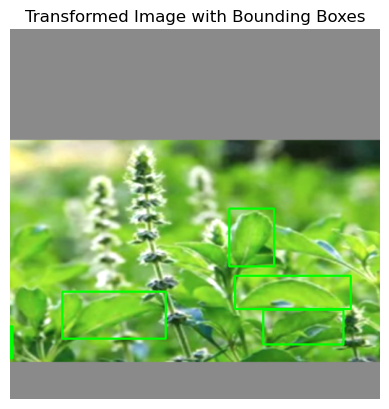

In [55]:
transformed = transform_pipeline(image=image, bboxes=bboxes, class_labels=[class_id] * len(bboxes))

transformed_image = transformed["image"]
transformed_bboxes = transformed["bboxes"]

# Draw transformed bounding boxes
for bbox in transformed_bboxes:
    x_center, y_center, width, height = bbox
    x_min = int((x_center - width / 2) * transformed_image.shape[1])
    y_min = int((y_center - height / 2) * transformed_image.shape[0])
    x_max = int((x_center + width / 2) * transformed_image.shape[1])
    y_max = int((y_center + height / 2) * transformed_image.shape[0])
    cv.rectangle(transformed_image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)

# Display transformed image
# Convert the image to RGB (OpenCV uses BGR by default)
transformed_image_rgb = cv.cvtColor(transformed_image, cv.COLOR_BGR2RGB)

plt.imshow(transformed_image_rgb)
plt.title("Transformed Image with Bounding Boxes")
plt.axis('off')  # Hide axes for a cleaner view
plt.show()

